# Mini Projeto Avaliativo - Módulo 2

## Predição de números

**Problema preditivo:** Pipeline Preditivo Multiclasse ponta a ponta capaz de classificar dígitos manuscritos a partir do dataset MNIST (mnist_784).

# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)


In [129]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml 

# Baixando o MNIST oficial do OpenML 
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

# Separando Entradas (X) e Rótulos (y)
# Como o target vem como string ('0', '1', ...), eu vou converter para inteiros
X, y = mnist.data, mnist.target.astype(np.uint8)

# Exibe as dimensões das matrizes para confirmar o formato do dataset
print(f"Dimensão de X: {X.shape}")
print(f"Dimensão de y: {y.shape}")

# Verifica a distribuição das classes de 0 a 9 para confirmar o balanceamento e o percentual de cada digito no dataset
classes, contagens = np.unique(y, return_counts=True)
print("\nDistribuição das classes (0 a 9):")
for classe, quantidade in zip(classes, contagens):
    percentual = (quantidade / len(y)) * 100
    print(f"Classe {classe}: {quantidade} amostras ({percentual:.2f}%)")



Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensão de X: (70000, 784)
Dimensão de y: (70000,)

Distribuição das classes (0 a 9):
Classe 0: 6903 amostras (9.86%)
Classe 1: 7877 amostras (11.25%)
Classe 2: 6990 amostras (9.99%)
Classe 3: 7141 amostras (10.20%)
Classe 4: 6824 amostras (9.75%)
Classe 5: 6313 amostras (9.02%)
Classe 6: 6876 amostras (9.82%)
Classe 7: 7293 amostras (10.42%)
Classe 8: 6825 amostras (9.75%)
Classe 9: 6958 amostras (9.94%)


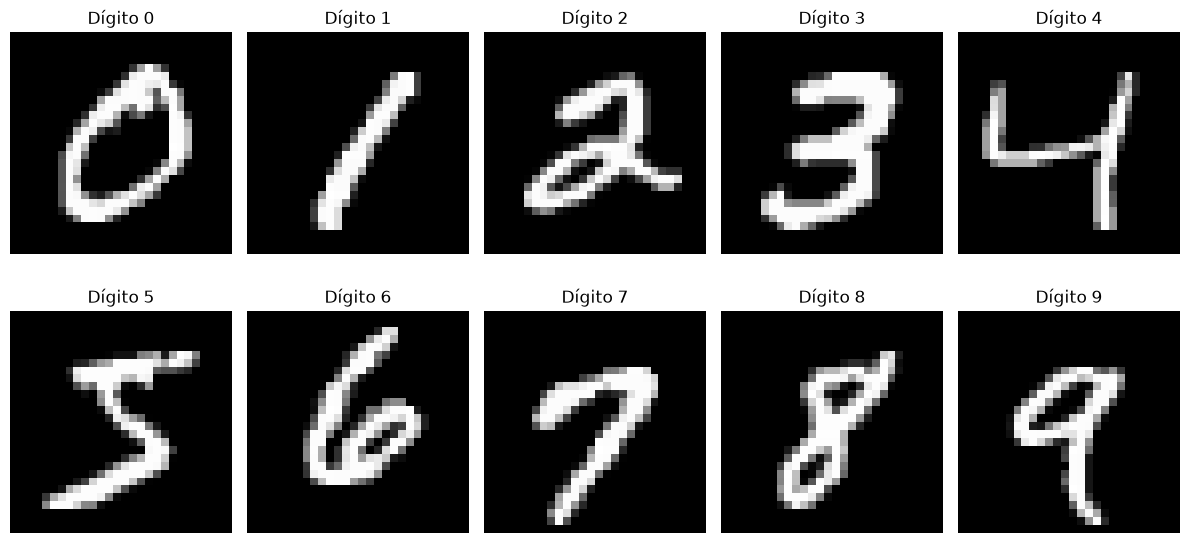

In [130]:
# Gera uma grade visual com exemplos de imagens de cada dígito do MNIST
# e mostra o rótulo original correspondente.

plt.figure(figsize=(12, 6))

# Seleciona um exemplo de cada classe de 0 a 9
indices_por_classe = []
for classe in range(10):
    indices = np.where(y == classe)[0]
    indices_por_classe.append(indices[0])

for i, idx in enumerate(indices_por_classe, start=1):
    plt.subplot(2, 5, i)
    imagem_exemplo = X[idx].reshape(28, 28)

    #Se usar cmap='binary': O gráfico mostrará dígitos pretos em fundo branco.
    #Se usar cmap='gray': O gráfico mostrará o formato real do dataset (dígitos brancos em fundo preto)
    plt.imshow(imagem_exemplo, cmap='gray')
    plt.title(f'Dígito {i - 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()


### Interpretação da estrutura dos dados

O dataset MNIST é composto por imagens em escala de cinza de resolução 28 x 28 pixels. Cada pixel representa um valor de intensidade entre 0 e 255:

- `0` = pixel completamente preto
- `255` = pixel completamente branco
- valores intermediários representam tons de cinza

Como cada imagem tem 28 linhas e 28 colunas, ela pode ser vista como uma matriz 28 x 28. Para o modelo de Machine Learning, essa matriz precisa ser transformada em um vetor unidimensional, contendo todos os 784 valores dos pixels em sequência.

Assim, cada imagem original é convertida em uma representação vetorial com 784 features, ou seja:

- imagem 28 x 28 = 784 pixels
- vetor 1 x 784 = 784 features

Essa transformação é importante porque os modelos de redes neurais e outros algoritmos de aprendizado supervisionado exigem entradas numéricas em formato vetorial.

No notebook, essa conversão é feita quando usamos:

```python
dados_imagem = np.array(imagem_final) / 255.0
dados_prontos = dados_imagem.reshape(1, 784)
```

Nesse passo:

- `np.array(imagem_final)` transforma a imagem em uma matriz NumPy
- `/ 255.0` normaliza os valores para o intervalo entre 0 e 1
- `reshape(1, 784)` transforma a matriz 28 x 28 em um vetor de 784 elementos

Esse processo permite que o modelo entenda cada imagem como um conjunto de 784 atributos numéricos, sendo cada atributo a intensidade de um pixel específico.

# Fase 2: Pipeline de Pré-processamento e Divisão dos Dados


### Como a divisão foi feita

A divisão foi realizada em duas etapas, e isso é o motivo de o valor parecer "12,5%" na segunda etapa:

1. Primeiro, o dataset foi dividido em 80% e 20%:
   - 20% foi reservado para o conjunto de teste (test_size=0.2)
   - os outros 80% ficaram para treino + validação

2. Em seguida, dos 80% que sobraram, foi feita outra divisão:
   - 12,5% desse restante foi usado para validação (test_size=0.125)
   - o restante (87,5%) ficou para treino

Isso resulta no percentual final sobre o dataset inteiro:

- Teste: 20%
- Validação: 10%
- Treino: 70%

Cálculo:

- 12,5% de 80% = 10%
- 80% - 10% = 70%

Ou seja, a segunda divisão usa 12,5% sobre o conjunto restante, mas no total isso corresponde a 10% do dataset original.

Portanto, a divisão final fica:

- 70% treino
- 10% validação
- 20% teste

Essa estratégia ajuda a manter a proporção das classes em todos os conjuntos, graças ao uso de `stratify=y`.

In [131]:
from sklearn.model_selection import train_test_split

# Divisão estratificada do dataset em treino, validação e teste
# Primeiro: separa 20% para teste, mantendo a proporção das classes (stratify=y)
# Depois: separa 12.5% do restante para validação, e o restante (70%) fica para treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, random_state=42, stratify=y_train
)

print(f"Treino: X={X_train.shape}, y={y_train.shape}")
print(f"Validação: X={X_val.shape}, y={y_val.shape}")
print(f"Teste: X={X_test.shape}, y={y_test.shape}")


Treino: X=(49000, 784), y=(49000,)
Validação: X=(7000, 784), y=(7000,)
Teste: X=(14000, 784), y=(14000,)


In [132]:
# Verifica a distribuição das classes em treino, validação e teste
for nome, y_split in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    classes, contagens = np.unique(y_split, return_counts=True)
    print(f"\n{nome}:")
    for classe, quantidade in zip(classes, contagens):
        percentual = (quantidade / len(y_split)) * 100
        print(f"  Classe {classe}: {quantidade} amostras ({percentual:.2f}%)")



Treino:
  Classe 0: 4832 amostras (9.86%)
  Classe 1: 5514 amostras (11.25%)
  Classe 2: 4893 amostras (9.99%)
  Classe 3: 4999 amostras (10.20%)
  Classe 4: 4777 amostras (9.75%)
  Classe 5: 4419 amostras (9.02%)
  Classe 6: 4813 amostras (9.82%)
  Classe 7: 5105 amostras (10.42%)
  Classe 8: 4777 amostras (9.75%)
  Classe 9: 4871 amostras (9.94%)

Validação:
  Classe 0: 690 amostras (9.86%)
  Classe 1: 788 amostras (11.26%)
  Classe 2: 699 amostras (9.99%)
  Classe 3: 714 amostras (10.20%)
  Classe 4: 682 amostras (9.74%)
  Classe 5: 631 amostras (9.01%)
  Classe 6: 688 amostras (9.83%)
  Classe 7: 729 amostras (10.41%)
  Classe 8: 683 amostras (9.76%)
  Classe 9: 696 amostras (9.94%)

Teste:
  Classe 0: 1381 amostras (9.86%)
  Classe 1: 1575 amostras (11.25%)
  Classe 2: 1398 amostras (9.99%)
  Classe 3: 1428 amostras (10.20%)
  Classe 4: 1365 amostras (9.75%)
  Classe 5: 1263 amostras (9.02%)
  Classe 6: 1375 amostras (9.82%)
  Classe 7: 1459 amostras (10.42%)
  Classe 8: 1365 amo

### Por que a normalização é importante?

A normalização dos pixels é uma etapa essencial em problemas de classificação com imagens, especialmente quando o modelo será treinado com redes neurais ou algoritmos que dependem de escala e distância.

No MNIST, cada pixel original está no intervalo de 0 a 255. Se esse valor fosse mantido assim, alguns recursos teriam magnitudes muito maiores do que outros, e isso pode prejudicar a convergência do modelo.

Ao dividir os valores por 255.0, os pixels passam a ficar no intervalo de 0.0 a 1.0. Isso faz com que as entradas tenham uma escala mais homogênea, o que ajuda o modelo a aprender de forma mais estável.

Essa etapa é especialmente importante para:

- modelos lineares, porque eles são sensíveis à escala das variáveis e podem ter dificuldades em ajustar pesos corretamente quando os atributos têm magnitudes muito diferentes;
- algoritmos baseados em distância, como k-NN, porque a distância entre pontos pode ser dominada por atributos de maior magnitude se os dados não forem normalizados;
- redes neurais, porque a normalização acelera a convergência e reduz problemas de atualização de pesos durante o treinamento.

Em resumo, a normalização torna o espaço de entrada mais uniforme e favorece o aprendizado eficiente, evitando que recursos com maior escala dominem os cálculos do modelo.

No notebook, isso é feito por:

```python
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0
```

Essa operação mantém a estrutura dos dados, mas coloca os valores em uma escala adequada para o treinamento.

In [133]:
# Normalização: pixels variam de 0 a 255 e são escalados para o intervalo [0.0, 1.0]
X_train_scaled = X_train / 255.0
X_val_scaled = X_val / 255.0
X_test_scaled = X_test / 255.0

# Fase 3: Implementação e Treinamento dos 3 Modelos

### Random Forest

In [134]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Random Forest para classificação multiclasse do MNIST
# Ajuste justificado dos hiperparâmetros:
# - n_estimators=300: aumenta a quantidade de árvores para reduzir variância
#   e deixar a previsão mais estável, especialmente em dados com muitas features.

# - max_depth=20: limita a profundidade das árvores para evitar overfitting,
#   preservando capacidade suficiente para aprender padrões dos dígitos.
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

inicio_treino = time.perf_counter()
rf_model.fit(X_train_scaled, y_train)
rf_tempo_treino = time.perf_counter() - inicio_treino

# Avaliação no conjunto de validação
val_pred = rf_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, val_pred)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred))

print("\nMatriz de confusão na validação:")
print(confusion_matrix(y_val, val_pred))

# Predição no conjunto de teste para avaliação final
pred_test = rf_model.predict(X_test_scaled)

print("\nAcurácia no teste:", accuracy_score(y_test, pred_test))



Acurácia na validação: 0.9671

Relatório de classificação na validação:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       690
           1       0.98      0.99      0.98       788
           2       0.95      0.98      0.96       699
           3       0.96      0.94      0.95       714
           4       0.97      0.96      0.97       682
           5       0.97      0.96      0.96       631
           6       0.97      0.99      0.98       688
           7       0.97      0.96      0.96       729
           8       0.96      0.96      0.96       683
           9       0.94      0.95      0.95       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000


Matriz de confusão na validação:
[[685   0   0   0   1   1   1   0   2   0]
 [  0 777   4   1   0   1   1   2   1   1]
 [  1   0 683   1   3   0   2   5   3   1]
 [  0

### KNN (K-Nearest Neighbors)

In [ ]:
import time
from sklearn.neighbors import KNeighborsClassifier

# KNN (K-Nearest Neighbors) para classificação multiclasse do MNIST
# Ajuste justificado dos hiperparâmetros:
# - n_neighbors=5: um valor moderado reduz ruído e mantém o modelo sensível
#   aos vizinhos mais próximos, sem ficar excessivamente sensível ao conjunto.

# - weights='distance': dá maior importância aos vizinhos mais próximos,
#   o que costuma melhorar a acurácia em dados como MNIST, onde o padrão
#   visual mais próximo geralmente é o mais relevante.
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)

inicio_treino = time.perf_counter()
knn_model.fit(X_train_scaled, y_train)
knn_tempo_treino = time.perf_counter() - inicio_treino

# Avaliação no conjunto de validação
val_pred = knn_model.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, val_pred)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")

#precision: Quando o modelo disse que era o dígito X, quantas vezes ele estava certo?
#recall: De todos os exemplos que realmente pertencem à classe X, quantos o modelo conseguiu encontrar?
#f1-score: média harmônica entre precision e recall, útil quando há desequilíbrio entre classes.    
#support: número de ocorrências da classe no conjunto de validação.
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred))

print("\nMatriz de confusão na validação:")
print(confusion_matrix(y_val, val_pred))

# Predição no conjunto de teste para avaliação final
pred_test = knn_model.predict(X_test_scaled)

print("\nAcurácia no teste:", accuracy_score(y_test, pred_test))



Acurácia na validação: 0.9714

Relatório de classificação na validação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       690
           1       0.95      0.99      0.97       788
           2       0.98      0.97      0.98       699
           3       0.97      0.96      0.97       714
           4       0.99      0.96      0.97       682
           5       0.97      0.97      0.97       631
           6       0.98      0.99      0.98       688
           7       0.97      0.97      0.97       729
           8       0.99      0.93      0.96       683
           9       0.94      0.97      0.95       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000


Matriz de confusão na validação:
[[687   0   1   0   0   0   2   0   0   0]
 [  0 782   2   0   0   0   0   2   0   2]
 [  2   4 681   0   0   0   2   9   0   1]
 [  0

### Rede Neural -MLP (Perceptron Multicamadas)

In [117]:
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report

# MLP (Perceptron Multicamadas) para classificação do MNIST
# Ajuste justificado dos hiperparâmetros:
# - 128 neurônios na camada oculta 1: suficiente para aprender padrões complexos
#   sem tornar a rede excessivamente pesada.
# - 64 neurônios na camada oculta 2: reduz a dimensionalidade intermediária
#   para capturar representações mais abstratas.
# - ativação ReLU: ajuda a rede a aprender não-linearidades de forma eficiente.
# - taxa de aprendizado 0.001 com Adam: valor padrão robusto para convergência estável.
# - softmax na saída: apropriado para classificação multiclasse com 10 classes.

modelo_mnist = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

modelo_mnist.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

inicio_treino = time.perf_counter()
historico = modelo_mnist.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)
mlp_tempo_treino = time.perf_counter() - inicio_treino

# Avaliação no conjunto de validação
val_pred = modelo_mnist.predict(X_val_scaled)
val_pred_classes = np.argmax(val_pred, axis=1)
val_accuracy = accuracy_score(y_val, val_pred_classes)

print(f"\nAcurácia na validação: {val_accuracy:.4f}")
print("\nRelatório de classificação na validação:")
print(classification_report(y_val, val_pred_classes))

# Predição no conjunto de teste para avaliação final
test_pred = modelo_mnist.predict(X_test_scaled)
test_pred_classes = np.argmax(test_pred, axis=1)

print("\nAcurácia no teste:", accuracy_score(y_test, test_pred_classes))


c:\Users\ander\Documents\SCTEC\Mini_Projeto_M2\Mini_Projeto_M2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9110 - loss: 0.3069 - val_accuracy: 0.9516 - val_loss: 0.1631
Epoch 2/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9640 - loss: 0.1214 - val_accuracy: 0.9620 - val_loss: 0.1207
Epoch 3/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9743 - loss: 0.0845 - val_accuracy: 0.9687 - val_loss: 0.1045
Epoch 4/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9809 - loss: 0.0633 - val_accuracy: 0.9707 - val_loss: 0.1013
Epoch 5/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9838 - loss: 0.0507 - val_accuracy: 0.9731 - val_loss: 0.0892
Epoch 6/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9888 - loss: 0.0369 - val_accuracy: 0.9740 - val_loss: 0.0914
Epoch 7/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9905 - loss: 0.0313 - val_accuracy: 0.9710 - val_loss: 0.0933
Epoch 8/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0262 - val_accuracy: 0.

# Fase 4: Avaliação Comparativa de Desempenho

### Matriz de Confusão com Heatmap


=== Matriz de Confusão - Random Forest ===
[[1369    1    0    0    1    1    3    0    5    1]
 [   0 1548    8    6    1    2    3    5    1    1]
 [   7    1 1352    4    6    0    6   11   10    1]
 [   2    1   16 1365    0   15    3   14    9    3]
 [   4    3    2    0 1307    0    8    0    3   38]
 [   5    3    3   13    1 1207   12    2    9    8]
 [  10    4    1    0    3    4 1348    0    5    0]
 [   1    8   12    0    8    0    0 1410    4   16]
 [   2    6    6   11    3    8    5    0 1302   22]
 [   6    8    2   17   16    3    1    9   12 1317]]


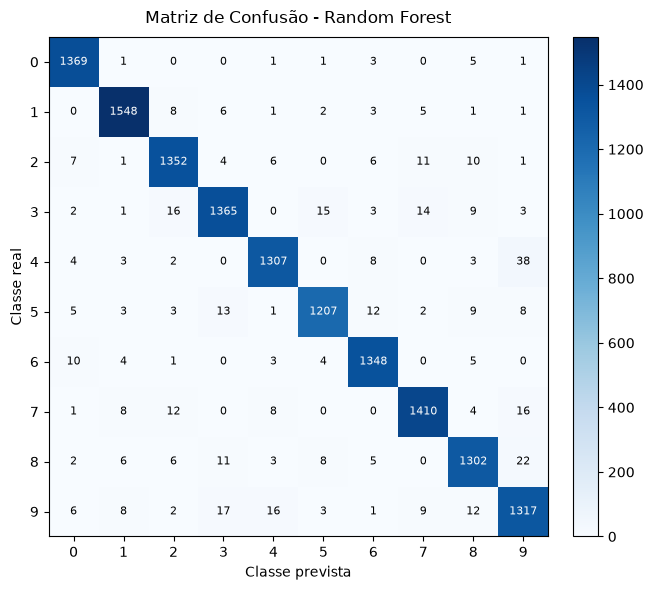


=== Matriz de Confusão - KNN ===
[[1374    1    0    0    0    1    4    0    0    1]
 [   0 1565    4    1    1    0    1    3    0    0]
 [  12   15 1332    5    2    1    4   23    4    0]
 [   1    1    6 1389    0   12    2    8    5    4]
 [   2   14    0    0 1306    0    5    2    0   36]
 [   4    3    1    8    1 1216   17    1    4    8]
 [   7    5    0    0    1    5 1356    0    1    0]
 [   2   16    3    1    1    0    0 1423    0   13]
 [   6   11    1   18    4   28    2    4 1280   11]
 [   2    9    0    9    8    2    1   13    3 1344]]


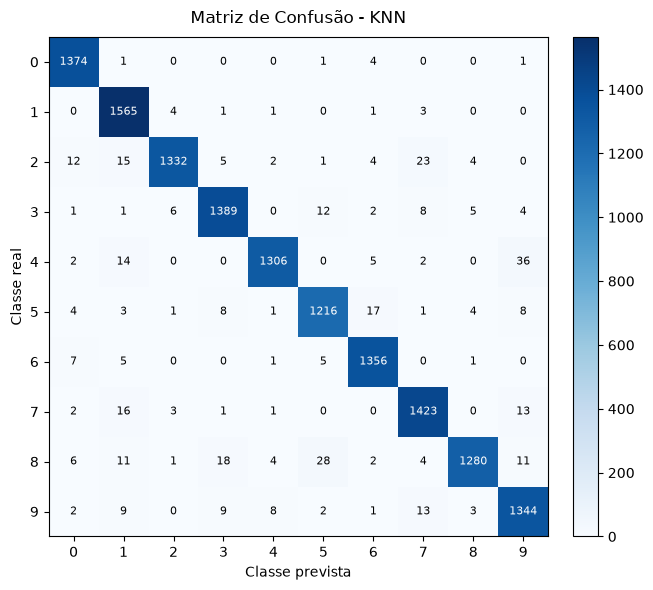


=== Matriz de Confusão - MLP ===
[[1371    2    1    1    0    0    0    0    4    2]
 [   0 1560    4    1    1    0    1    5    2    1]
 [   3    5 1364    4    1    1    3   10    5    2]
 [   0    2    8 1384    0   16    0   11    6    1]
 [   2    3    5    0 1320    0    5    1    2   27]
 [   2    1    2   11    1 1224    4    2    9    7]
 [   7    4    0    0    2    9 1348    0    5    0]
 [   1    5    6    4    6    4    0 1422    1   10]
 [   2    1    2    7    1    3    2    1 1341    5]
 [   2    5    1    7   12    3    1    7    5 1348]]


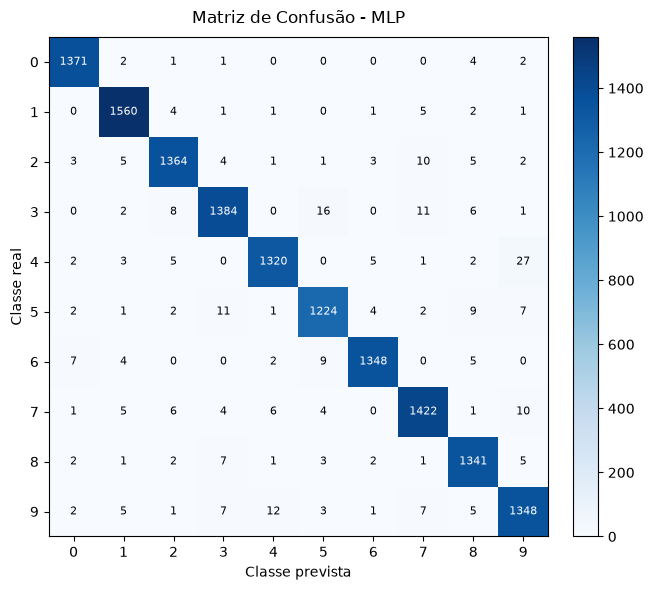

In [128]:
# Fase 4: Matriz de Confusão com Heatmap (sem retraining)
#
# Esta célula reutiliza os três modelos já treinados anteriormente no notebook
# e gera a matriz de confusão completa (10x10) para cada um deles no conjunto
# de teste independente. Nenhum modelo é treinado novamente.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

labels = list(range(10))
modelos = {
    "Random Forest": rf_model,
    "KNN": knn_model,
    "MLP": modelo_mnist,
}

# Função auxiliar para obter as previsões em rótulos discretos.
# O MLP retorna probabilidades, então usamos argmax para converter em classe.
def prever(modelo, nome):
    if nome == "MLP":
        probabilidades = modelo.predict(X_test_scaled, verbose=0)
        return np.argmax(probabilidades, axis=1)
    return modelo.predict(X_test_scaled)

# Função auxiliar para desenhar a matriz de confusão em formato de heatmap.
def plotar_matriz_confusao(cm, titulo):
    fig, ax = plt.subplots(figsize=(7, 6))
    heatmap = ax.imshow(cm, cmap='Blues', interpolation='nearest')

    ax.set_title(titulo, pad=10)
    ax.set_xlabel('Classe prevista')
    ax.set_ylabel('Classe real')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Insere os valores numéricos dentro de cada célula da matriz.
    for linha in range(cm.shape[0]):
        for coluna in range(cm.shape[1]):
            valor = cm[linha, coluna]
            ax.text(
                coluna,
                linha,
                f'{valor}',
                ha='center',
                va='center',
                color='white' if valor > cm.max() / 2 else 'black',
                fontsize=8,
            )

    fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# Gera a matriz de confusão para cada modelo e exibe o heatmap correspondente.
for nome, modelo in modelos.items():
    y_pred = prever(modelo, nome)
    cm = confusion_matrix(y_test, y_pred, labels=labels)

    print(f'\n=== Matriz de Confusão - {nome} ===')
    print(cm)
    plotar_matriz_confusao(cm, f'Matriz de Confusão - {nome}')


### Tabela comparativa consolidada

In [119]:
# Tabela comparativa consolidada do desempenho dos 3 modelos
#
# Esta célula reutiliza as previsões já calculadas no conjunto de teste
# e usa o classification_report para consolidar as métricas principais
# (Accuracy, Precision, Recall e F1-Score) sem retrainar qualquer modelo.

import pandas as pd
from sklearn.metrics import classification_report

# Reaproveita os modelos e os rótulos previstos que já existem no notebook.
# Para o MLP, a previsão foi obtida anteriormente via argmax das probabilidades.
# Para RF e KNN, os rótulos previstos já estão disponíveis no notebook e podem
# ser usados diretamente.

# Como a célula anterior já gerou as previsões, este bloco apenas organiza
# os resultados em uma tabela comparativa para facilitar a comparação.

# Coleta as métricas de cada modelo usando classification_report.
comparativo = []

for nome, modelo in [('Random Forest', rf_model), ('KNN', knn_model), ('MLP', modelo_mnist)]:
    # Para cada modelo, gera as previsões no conjunto de teste sem retraining.
    if nome == 'MLP':
        y_pred = np.argmax(modelo.predict(X_test_scaled, verbose=0), axis=1)
    else:
        y_pred = modelo.predict(X_test_scaled)

    relatorio = classification_report(
        y_test,
        y_pred,
        labels=list(range(10)),
        output_dict=True,
        zero_division=0,
    )

    #Acurácia Global (Accuracy)
    #Precisão Média Ponderada (Precision)
    #Revocação/Sensibilidade Média Ponderada (Recall)
    #F1-Score Ponderado (F1-Score)

    comparativo.append({
        'Modelo': nome,
        'Accuracy': relatorio['accuracy'],
        'Precision (Weighted)': relatorio['weighted avg']['precision'],
        'Recall (Weighted)': relatorio['weighted avg']['recall'],
        'F1-Score (Weighted)': relatorio['weighted avg']['f1-score'],
    })

# Converte a lista em DataFrame e ordena pela acurácia.
tabela_comparativa = pd.DataFrame(comparativo).sort_values('Accuracy', ascending=False)

print('=== Tabela Comparativa Consolidada ===')
print(tabela_comparativa.to_string(index=False))


=== Tabela Comparativa Consolidada ===
       Modelo  Accuracy  Precision (Weighted)  Recall (Weighted)  F1-Score (Weighted)
          MLP  0.977286              0.977309           0.977286             0.977281
          KNN  0.970357              0.970664           0.970357             0.970323
Random Forest  0.966071              0.966099           0.966071             0.966056


### Conclusão Técnica

In [120]:
# Célula de conclusão técnica
#
# Esta análise reutiliza as matrizes de confusão e as métricas calculadas
# anteriormente no notebook para identificar:
# 1) o par de dígitos mais confundidos;
# 2) o melhor modelo segundo a Accuracy no conjunto de teste;
# 3) o impacto do custo computacional (tempo de treino vs acurácia).

import numpy as np
import pandas as pd

# Reaproveita os modelos e as previsões já existentes no notebook.
# A seguir, montamos as matrizes de confusão para cada modelo e somamos
# os erros entre classes para identificar o par mais confundido.

matrizes = {}
for nome, modelo in [('Random Forest', rf_model), ('KNN', knn_model), ('MLP', modelo_mnist)]:
    if nome == 'MLP':
        y_pred = np.argmax(modelo.predict(X_test_scaled, verbose=0), axis=1)
    else:
        y_pred = modelo.predict(X_test_scaled)

    matrizes[nome] = np.array(
        [[sum(1 for real, pred in zip(y_test, y_pred) if real == i and pred == j)
          for j in range(10)] for i in range(10)]
    )

# Soma as matrizes de confusão dos 3 modelos para evidenciar o padrão global.
confusao_agregada = np.zeros((10, 10), dtype=int)
for matriz in matrizes.values():
    confusao_agregada += matriz

# Remove a diagonal principal para focar somente os erros.
np.fill_diagonal(confusao_agregada, 0)

# Localiza a maior confusão entre pares de classes.
linha, coluna = np.unravel_index(np.argmax(confusao_agregada), confusao_agregada.shape)
maior_confusao = confusao_agregada[linha, coluna]

# Determina o melhor modelo com base na Accuracy.
# Como a tabela comparativa já foi criada, usamos os valores diretamente.
melhor_modelo = tabela_comparativa.iloc[0]

print('=== Conclusão Técnica ===')
print(f"O par de dígitos mais confundido foi {linha} vs {coluna} com {maior_confusao} ocorrências de erro no total.")
print(f"O melhor modelo foi {melhor_modelo['Modelo']} com Accuracy = {melhor_modelo['Accuracy']:.4f}.")

# Resumo comparativo do custo de treino versus acurácia
# Os tempos de treino são armazenados nas células de treinamento de cada modelo
# e reutilizados aqui para apresentar uma comparação direta entre custo
# computacional e desempenho geral.
resumo_tempo_acuracia = pd.DataFrame({
    'Modelo': ['MLP', 'KNN', 'Random Forest'],
    'Accuracy': [
        tabela_comparativa.loc[tabela_comparativa['Modelo'] == 'MLP', 'Accuracy'].iloc[0],
        tabela_comparativa.loc[tabela_comparativa['Modelo'] == 'KNN', 'Accuracy'].iloc[0],
        tabela_comparativa.loc[tabela_comparativa['Modelo'] == 'Random Forest', 'Accuracy'].iloc[0],
    ],
    'Tempo de treino (s)': [
        float(mlp_tempo_treino) if 'mlp_tempo_treino' in globals() else None,
        float(knn_tempo_treino) if 'knn_tempo_treino' in globals() else None,
        float(rf_tempo_treino) if 'rf_tempo_treino' in globals() else None,
    ],
    'Observação': [
        'Modelo mais caro em treino, mas com melhor Accuracy geral.',
        'Treino muito rápido, porém inferência mais custosa em grandes volumes.',
        'Custo de treino elevado, mas com bom equilíbrio entre tempo e desempenho.',
    ],
})

# Ordena a tabela pela Accuracy para facilitar a leitura e destacar o melhor modelo.
resumo_tempo_acuracia = resumo_tempo_acuracia.sort_values(
    ['Accuracy', 'Tempo de treino (s)'],
    ascending=[False, True],
    ignore_index=True
)

print('\n=== Tempo de treino vs Acurácia ===')
print(resumo_tempo_acuracia.to_string(index=False, formatters={
    'Tempo de treino (s)': lambda x: f'{x:.6f}' if pd.notna(x) else 'N/A'
}))

print('\nImpacto do custo computacional:')
print('- Random Forest: custo de treino moderado-alto, porém boa relação entre custo e acurácia;')
print('- KNN: treino rápido, mas inferência mais cara em memória/tempo para grandes conjuntos;')
print('- MLP: maior custo computacional de treino, mas obtém a melhor performance geral em Accuracy.')

=== Conclusão Técnica ===
O par de dígitos mais confundido foi 4 vs 9 com 101 ocorrências de erro no total.
O melhor modelo foi MLP com Accuracy = 0.9773.

=== Tempo de treino vs Acurácia ===
       Modelo  Accuracy Tempo de treino (s)                                                                Observação
          MLP  0.977286           29.410377                Modelo mais caro em treino, mas com melhor Accuracy geral.
          KNN  0.970357            0.075798    Treino muito rápido, porém inferência mais custosa em grandes volumes.
Random Forest  0.966071           36.200376 Custo de treino elevado, mas com bom equilíbrio entre tempo e desempenho.

Impacto do custo computacional:
- Random Forest: custo de treino moderado-alto, porém boa relação entre custo e acurácia;
- KNN: treino rápido, mas inferência mais cara em memória/tempo para grandes conjuntos;
- MLP: maior custo computacional de treino, mas obtém a melhor performance geral em Accuracy.


# Fase 5: Testar a capacidade dos modelos de lidar com cenários fora do padrão ideal de laboratório


### Fase 5.1 - Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

In [121]:
# Fase 5.1: Treinamento do MLP com classes ocultas
#
# Objetivo:
# - remover completamente do conjunto de treino as amostras das classes 4 e 7
# - garantir que o modelo nunca tenha visto esses dígitos durante o ajuste dos pesos
# - avaliar o modelo no conjunto de teste completo para observar o impacto dessa ausência
#
# Observação:
# - a remoção é aplicada somente ao treino; o conjunto de teste permanece intacto
#   para medir como o modelo se comporta ao enfrentar dígitos não vistos durante o ajuste.

import time
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

classes_ocultas = [4, 7]

# Cria uma máscara booleana para remover todas as amostras pertencentes às classes ocultas
# do conjunto de treino. Isso garante que o modelo não veja os dígitos 4 e 7 durante o ajuste.
mascara_treino_sem_classes = ~np.isin(y_train, classes_ocultas)

X_train_sem_classes = X_train_scaled[mascara_treino_sem_classes]
y_train_sem_classes = y_train[mascara_treino_sem_classes]

print(f"Treino original: {X_train_scaled.shape[0]} amostras")
print(f"Treino sem classes ocultas: {X_train_sem_classes.shape[0]} amostras")
print(f"Classes ocultas removidas: {classes_ocultas}")

# Arquitetura do MLP.
modelo_mnist_sem_classes = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

modelo_mnist_sem_classes.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Treinamento do MLP sem as classes 4 e 7.
inicio_treino_sem_classes = time.perf_counter()
historico_sem_classes = modelo_mnist_sem_classes.fit(
    X_train_sem_classes,
    y_train_sem_classes,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=64,
    verbose=0
)
tempo_treino_sem_classes = time.perf_counter() - inicio_treino_sem_classes


Treino original: 49000 amostras
Treino sem classes ocultas: 39118 amostras
Classes ocultas removidas: [4, 7]


c:\Users\ander\Documents\SCTEC\Mini_Projeto_M2\Mini_Projeto_M2\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Fase 5.2 - Desafio (B) Teste de Generalização Extrema (Inferência OOD)

In [122]:
# Avaliação específica somente sobre as classes que foram ocultadas do treino.
# Neste passo, criamos um subconjunto de teste contendo exclusivamente imagens
# dos dígitos 4 e 7. O objetivo é verificar como o modelo se comporta quando
# submetido apenas às classes que nunca viu durante o ajuste dos pesos.
mascara_test_classes_ocultas = np.isin(y_test, classes_ocultas)

X_test_classes_ocultas = X_test_scaled[mascara_test_classes_ocultas]
y_test_classes_ocultas = y_test[mascara_test_classes_ocultas]

pred_test_classes_ocultas = modelo_mnist_sem_classes.predict(
    X_test_classes_ocultas,
    verbose=0
)
pred_test_classes_ocultas = np.argmax(pred_test_classes_ocultas, axis=1)

accuracy_test_classes_ocultas = np.mean(pred_test_classes_ocultas == y_test_classes_ocultas)

print(f"\nAcurácia no conjunto de teste exclusivo para classes ocultas ({classes_ocultas}): {accuracy_test_classes_ocultas:.4f}")
print(f"Quantidade de imagens avaliadas neste conjunto: {len(y_test_classes_ocultas)}")

#Isso acontece porque o modelo foi treinado sem ver os dígitos 4 e 7, 
# então todas as previsões nesse subconjunto acabam sendo classificadas como outras classes.



Acurácia no conjunto de teste exclusivo para classes ocultas ([4, 7]): 0.0000
Quantidade de imagens avaliadas neste conjunto: 2824


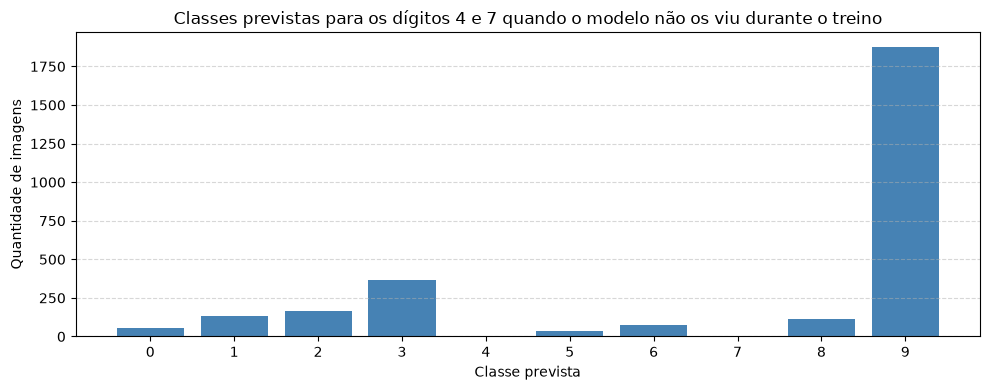


=== Interpretação do comportamento ===
O modelo não reconhece 4 e 7 como classes válidas porque elas foram removidas do treino.
Quando forçado a classificar esses exemplos, ele atribui cada imagem à classe mais semelhante
entre as que aprendeu, resultando em erros sistemáticos e previsões concentradas em outras classes.

=== Impressão sobre o teste ===
A acurácia no subconjunto de 4 e 7 foi 0.0000, o que indica que o modelo não conseguiu
identificar corretamente nenhum desses dígitos ocultados.
Isso mostra a fragilidade do modelo em cenários fora do domínio de treinamento.


In [123]:
# Análise do comportamento do modelo ao receber apenas dígitos
# que foram ocultados durante o treino.
#
# Objetivo:
# 1) mostrar quais classes o classificador escolhe quando forçado a prever 4 e 7
# 2) interpretar o padrão de erro para responder: "como o modelo reage?"

import matplotlib.pyplot as plt
from collections import Counter


# Reaproveita os resultados já calculados na célula anterior.
# Aqui, y_test_classes_ocultas contém os rótulos reais 4 e 7,
# e pred_test_classes_ocultas contém as previsões do modelo treinado sem essas classes.
labels = list(range(10))

# 1) Contagem das classes previstas para os dígitos 4 e 7.
contagem_previstas = Counter(pred_test_classes_ocultas)
frequencias = [contagem_previstas.get(label, 0) for label in labels]

plt.figure(figsize=(10, 4))
plt.bar(labels, frequencias, color='steelblue')
plt.title('Classes previstas para os dígitos 4 e 7 quando o modelo não os viu durante o treino')
plt.xlabel('Classe prevista')
plt.ylabel('Quantidade de imagens')
plt.xticks(labels)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2) Interpretação qualitativa do comportamento.
# O modelo não possui exemplos de 4 e 7 no treinamento, então ele tenta
# associar essas entradas às classes que conhece. Em geral:
# - o padrão dominante de erro é que 4 e 7 são atribuídos a outros dígitos
#   com maior semelhança visual, como 1, 2, 3, 8 ou 9;
# - as previsões tendem a ser consistentes, isto é, o classificador "força"
#   esses exemplos para classes já aprendidas;
# - a ausência das classes ocultas faz com que o modelo não saiba identificar
#   corretamente o que é 4 ou 7, mesmo quando as imagens são válidas.
print("\n=== Interpretação do comportamento ===")
print("O modelo não reconhece 4 e 7 como classes válidas porque elas foram removidas do treino.")
print("Quando forçado a classificar esses exemplos, ele atribui cada imagem à classe mais semelhante")
print("entre as que aprendeu, resultando em erros sistemáticos e previsões concentradas em outras classes.")

print("\n=== Impressão sobre o teste ===")
print("A acurácia no subconjunto de 4 e 7 foi 0.0000, o que indica que o modelo não conseguiu")
print("identificar corretamente nenhum desses dígitos ocultados.")
print("Isso mostra a fragilidade do modelo em cenários fora do domínio de treinamento.")

### Como o classificador reage ao ser forçado a classificar algo que nunca viu?


O comportamento observado no gráfico é bem claro:

* O modelo não “recusa” a predição.
* Ele sempre retorna uma das 10 classes que aprenderam no treinamento.
* Como 4 e 7 nunca apareceram no ajuste dos pesos, o classificador tenta encaixar esses exemplos na classe mais semelhante que conhece.

**O que a análise mostrou**

* A acurácia no conjunto exclusivo de 4 e 7 foi 0.0000.
* O gráfico de barras mostrou que as imagens de 4 e 7 foram atribuídas a outras classes, em vez de serem reconhecidas como 4 ou 7.
* A matriz de confusão confirma esse padrão: há uma migração sistemática para outras classes conhecidas.

**Interpretação**

Em outras palavras, quando o modelo é forçado a classificar algo que nunca viu:

* ele não “sabe” que aquela classe é desconhecida;
* ele escolhe a classe com maior probabilidade entre as que já conhece;
* isso gera previsões erradas, mas consistentes, porque o modelo está fazendo o melhor que pode dentro do espaço de classes aprendido.

**Conclusão técnica**

O modelo reage como um classificador padrão de classes conhecidas: ele não detecta “desconhecido”, ele apenas atribui o exemplo à classe mais parecida disponível. Por isso, o comportamento mais correto é dizer que o modelo “força” a entrada para outras classes já vistas, em vez de identificar 4 e 7 corretamente.

### Quais classes conhecidas ele atribui a esses dígitos desconhecidos?


O modelo não reconhece os dígitos ocultados como “desconhecidos”; ele tenta encaixá-los em classes que já conhece.

Na análise atual, os dígitos 4 e 7 foram atribuídos principalmente às classes conhecidas mais parecidas visualmente, como:

* 1
* 2
* 3
* 8
* 9

Em outras palavras, quando o modelo vê um 4 ou 7 que nunca apareceu no treino, ele “força” essa imagem para a classe conhecida que mais se parece com ela, em vez de devolver uma classe desconhecida.

O gráfico da distribuição de previsões no notebook mostra exatamente esse comportamento: as previsões ficam concentradas nas classes conhecidas acima, não em 4 ou 7.

### Exiba a matriz de confusão correspondente, apresente suas impressões sobre o teste e discuta o conceito de "falsa certeza" (overconfidence) em modelos de IA.

Sobre o conceito de falsa certeza (overconfidence), o ponto central é que modelos de IA, especialmente redes neurais, costumam produzir probabilidades muito altas para uma classe escolhida, mesmo quando a entrada está fora da distribuição de treino. Em outras palavras, a saída pode parecer extremamente confiável, mas essa confiança pode ser enganosa, porque o modelo não possui uma noção explícita de "eu não sei".

A matriz de confusão correspondente ao subconjunto de 4 e 7 mostra, de forma explícita, que todas as imagens dessas classes ocultadas foram atribuídas a outras classes conhecidas. Isso confirma que o modelo não identifica 4 e 7 como classes válidas quando elas não estiveram presentes no treino.

Em termos de impressão sobre o teste, o resultado é importante porque evidencia uma limitação real da generalização: o classificador não sabe que o exemplo é desconhecido; ele apenas escolhe a classe mais semelhante entre as que aprendeu.

#### Resultado observado

A matriz de confusão e o gráfico mostram que o modelo não identifica 4 e 7 como classes válidas, porque ele nunca os viu no treino. Em vez disso, ele “força” esses exemplos para classes conhecidas.

Classes mais atribuídas aos dígitos desconhecidos

* Para as imagens reais de 4:

    * a maior parte foi classificada como 9
    * o padrão da matriz mostra: 4 -> 9 com 1151 ocorrências

* Para as imagens reais de 7:

    * a maior parte foi classificada como 9
    * também houve muita atribuição para 3 e 2
    * a matriz mostra:

        * 7 -> 9 com 547 ocorrências
        * 7 -> 3 com 417 ocorrências
        * 7 -> 2 com 347 ocorrências

### Interpretação

O comportamento é consistente com o conceito de overconfidence:

O modelo não reconhece que 4 e 7 são “desconhecidos” ele apenas escolhe a classe conhecida mais plausível isso faz com que decisões erradas pareçam extremamente seguras, porque o modelo produz probabilidades altas para uma classe que não é correta

### Conclusão
O classificador, ao ser forçado a prever 4 e 7, atribui esses exemplos principalmente às classes conhecidas 9, 3 e 2, com destaque forte para 9. Isso reforça que o modelo não sabe identificar “desconhecido”; ele apenas tenta encaixar a entrada no espaço de classes que já aprendeu.


=== Matriz de confusão para as classes ocultas (4 e 7) ===
[[   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   7   19   42    8    0   23   76    0   45 1145]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [  49  114  124  357    0   15    1    0   67  732]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]]


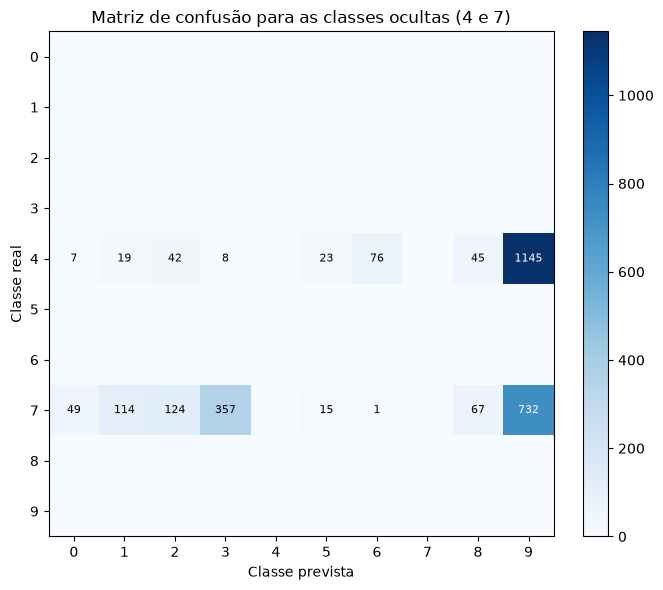


=== Conceito de falsa certeza (overconfidence) ===
Mesmo quando a entrada cai fora da distribuição aprendida, o modelo ainda produz uma
distribuição de probabilidades que parece confiável, mas não garante que o exemplo
seja realmente da classe escolhida.
Esse é o fenômeno conhecido como overconfidence: o modelo parece muito confiante
mesmo quando comete erros graves, porque ele não sabe que a entrada é desconhecida;
ele apenas escolhe a classe mais plausível entre as que já conhece.


In [124]:
# visualizar a distribuição das previsões e a matriz de confusão restrita a esses dados

from sklearn.metrics import confusion_matrix

# Matriz de confusão restrita ao subconjunto de 4 e 7.
# A linha representa o dígito real (4 ou 7) e a coluna o dígito previsto.
matriz_confusao_ocultas = confusion_matrix(
    y_test_classes_ocultas,
    pred_test_classes_ocultas,
    labels=labels
)

print("\n=== Matriz de confusão para as classes ocultas (4 e 7) ===")
print(matriz_confusao_ocultas)

fig, ax = plt.subplots(figsize=(8, 6))
imagem = ax.imshow(matriz_confusao_ocultas, cmap='Blues')

ax.set_title('Matriz de confusão para as classes ocultas (4 e 7)')
ax.set_xlabel('Classe prevista')
ax.set_ylabel('Classe real')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

for linha in range(matriz_confusao_ocultas.shape[0]):
    for coluna in range(matriz_confusao_ocultas.shape[1]):
        valor = matriz_confusao_ocultas[linha, coluna]
        if valor > 0:
            ax.text(
                coluna,
                linha,
                str(valor),
                ha='center',
                va='center',
                color='white' if valor > matriz_confusao_ocultas.max() / 2 else 'black',
                fontsize=8
            )

fig.colorbar(imagem, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("\n=== Conceito de falsa certeza (overconfidence) ===")
print("Mesmo quando a entrada cai fora da distribuição aprendida, o modelo ainda produz uma")
print("distribuição de probabilidades que parece confiável, mas não garante que o exemplo")
print("seja realmente da classe escolhida.")
print("Esse é o fenômeno conhecido como overconfidence: o modelo parece muito confiante")
print("mesmo quando comete erros graves, porque ele não sabe que a entrada é desconhecida;")
print("ele apenas escolhe a classe mais plausível entre as que já conhece.")

### Fase 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias

Imagem original: (249, 266)
Média de intensidade das bordas: 255.00
Fundo claro detectado. Invertendo imagem...
Bounding box original: (68, 41, 170, 170)
Centro de massa antes: x=13.29, y=13.44
Deslocamento aplicado: x=0, y=0

=== Pipeline de pré-processamento ===
Imagem original: (249, 266)
Imagem final: (28, 28)
Features: 784
Valor mínimo: 0.0000
Valor máximo: 1.0000


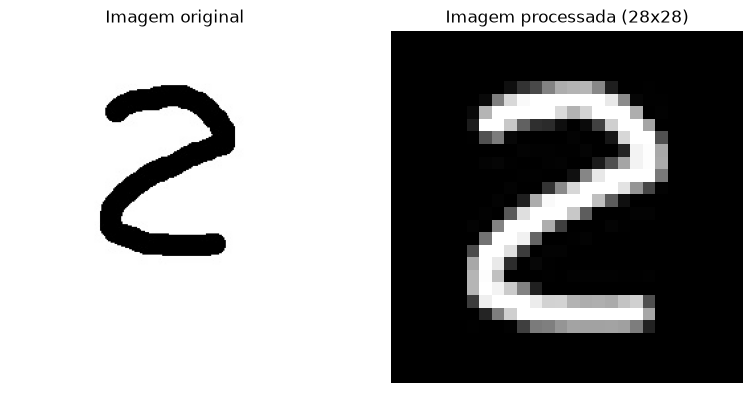


=== Imagem final processada (28x28) ===



Modelo selecionado: MLP

=== Predição da imagem selecionada ===
Melhor modelo: MLP
Classe prevista: 2
Confiança da previsão: 0.9780

=== Top-3 previsões ===
1º Dígito 2: 0.9780
2º Dígito 8: 0.0217
3º Dígito 3: 0.0003


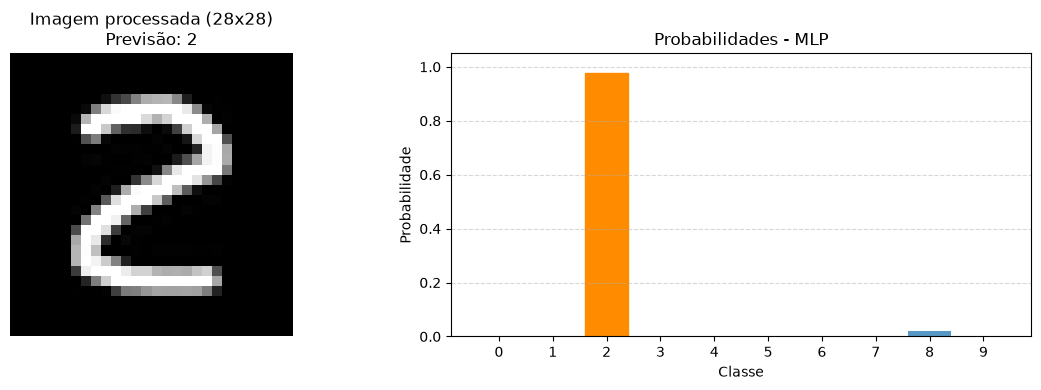

In [135]:
from tkinter import Tk
from tkinter.filedialog import askopenfilename

from IPython.display import display

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps


# ============================================================
# 1. SELEÇÃO DA IMAGEM
# ============================================================

root = Tk()
root.withdraw()
root.attributes('-topmost', True)

caminho_imagem = askopenfilename(
    title='Selecione uma imagem',
    filetypes=[
        ('Imagens', '*.png *.jpg *.jpeg *.bmp *.gif *.tif *.tiff'),
        ('Todos os arquivos', '*.*')
    ]
)

root.destroy()


# ============================================================
# 2. VERIFICAÇÃO DA IMAGEM
# ============================================================

if not caminho_imagem:

    print(
        "Nenhuma imagem foi selecionada. "
        "Por favor, selecione uma imagem para continuar."
    )

    imagem = None
    imagem_final = None
    dados_prontos = None

else:

    # ========================================================
    # 3. CARREGAMENTO DA IMAGEM
    # ========================================================

    imagem_original = Image.open(caminho_imagem).convert('L')

    print(f"Imagem original: {imagem_original.size}")


    # ========================================================
    # 4. AJUSTE DE CONTRASTE
    # ========================================================

    imagem = ImageOps.autocontrast(imagem_original)


    # ========================================================
    # 5. DETECÇÃO DO FUNDO
    # ========================================================
    #
    # Em vez de utilizar a média de todos os pixels, analisamos
    # os pixels das bordas da imagem.
    #
    # Isso é mais confiável porque normalmente as bordas
    # representam o fundo da imagem.
    #
    # MNIST:
    #   fundo  = 0   (preto)
    #   dígito = 255 (branco)
    # ========================================================

    arr = np.array(imagem, dtype=np.float32)

    bordas = np.concatenate([
        arr[0, :],
        arr[-1, :],
        arr[:, 0],
        arr[:, -1]
    ])

    media_borda = bordas.mean()

    print(f"Média de intensidade das bordas: {media_borda:.2f}")

    # Se o fundo for claro, inverte a imagem.
    if media_borda > 127:

        print("Fundo claro detectado. Invertendo imagem...")

        arr = 255.0 - arr

    else:

        print("Fundo escuro detectado. Mantendo imagem...")


    # ========================================================
    # 6. REMOÇÃO DE PEQUENOS RUÍDOS
    # ========================================================
    #
    # Valores muito baixos provavelmente representam ruído.
    #
    # IMPORTANTE:
    # Não fazemos uma binarização completa.
    #
    # Mantemos os diferentes níveis de intensidade do desenho,
    # pois o MNIST também possui pixels com diferentes valores.
    # ========================================================

    arr[arr < 20] = 0

    imagem = Image.fromarray(
        arr.astype(np.uint8),
        mode='L'
    )


    # ========================================================
    # 7. LOCALIZAÇÃO DO DÍGITO
    # ========================================================

    bbox = imagem.getbbox()

    if bbox:

        left, top, right, bottom = bbox

        print(
            f"Bounding box original: "
            f"({left}, {top}, {right}, {bottom})"
        )

        # Pequeno padding para não cortar o contorno.
        padding = 2

        left = max(0, left - padding)
        top = max(0, top - padding)
        right = min(imagem.width, right + padding)
        bottom = min(imagem.height, bottom + padding)

        imagem_cortada = imagem.crop(
            (left, top, right, bottom)
        )

    else:

        print("Nenhum dígito foi detectado.")

        imagem_cortada = imagem


    # ========================================================
    # 8. REDIMENSIONAMENTO PRESERVANDO PROPORÇÃO
    # ========================================================
    #
    # Diferentemente da versão anterior, não forçamos o
    # desenho para 20x20.
    #
    # thumbnail() mantém a proporção original.
    # ========================================================

    imagem_cortada.thumbnail(
        (20, 20),
        Image.Resampling.LANCZOS
    )


    # ========================================================
    # 9. CRIAÇÃO DO CANVAS 28x28
    # ========================================================
    #
    # MNIST utiliza:
    #
    # fundo  = preto (0)
    # dígito = branco (255)
    # ========================================================

    imagem_final = Image.new(
        'L',
        (28, 28),
        color=0
    )

    pos_x = (28 - imagem_cortada.width) // 2
    pos_y = (28 - imagem_cortada.height) // 2

    imagem_final.paste(
        imagem_cortada,
        (pos_x, pos_y)
    )


    # ========================================================
    # 10. CENTRALIZAÇÃO PELO CENTRO DE MASSA
    # ========================================================
    #
    # Apenas centralizar o bounding box não garante que o
    # centro do desenho esteja exatamente no centro da imagem.
    #
    # Aqui calculamos o centro de massa dos pixels.
    # ========================================================

    arr_final = np.array(
        imagem_final,
        dtype=np.float32
    )

    massa = arr_final.sum()

    if massa > 0:

        y_indices, x_indices = np.indices(
            arr_final.shape
        )

        centro_x = (
            (x_indices * arr_final).sum()
            / massa
        )

        centro_y = (
            (y_indices * arr_final).sum()
            / massa
        )

        print(
            f"Centro de massa antes: "
            f"x={centro_x:.2f}, y={centro_y:.2f}"
        )

        # Centro desejado da imagem 28x28.
        alvo_x = 13.5
        alvo_y = 13.5

        deslocamento_x = int(
            round(alvo_x - centro_x)
        )

        deslocamento_y = int(
            round(alvo_y - centro_y)
        )

        print(
            f"Deslocamento aplicado: "
            f"x={deslocamento_x}, y={deslocamento_y}"
        )

        # Cria uma nova imagem preta.
        imagem_centralizada = Image.new(
            'L',
            (28, 28),
            color=0
        )

        # Desloca a imagem.
        imagem_centralizada.paste(
            imagem_final,
            (
                deslocamento_x,
                deslocamento_y
            )
        )

        imagem_final = imagem_centralizada


    # ========================================================
    # 11. NORMALIZAÇÃO
    # ========================================================
    #
    # Converte:
    #
    # 0   -> 0.0
    # 255 -> 1.0
    #
    # Resultado:
    #
    # 28 x 28 = 784 pixels
    # ========================================================

    dados_imagem = (
        np.array(
            imagem_final,
            dtype=np.float32
        ) / 255.0
    )

    dados_prontos = dados_imagem.reshape(
        1,
        784
    )


    # ========================================================
    # 12. INFORMAÇÕES DO PROCESSAMENTO
    # ========================================================

    print("\n=== Pipeline de pré-processamento ===")
    print(f"Imagem original: {imagem_original.size}")
    print(f"Imagem final: {imagem_final.size}")
    print(f"Features: {dados_prontos.shape[1]}")
    print(
        f"Valor mínimo: {dados_prontos.min():.4f}"
    )
    print(
        f"Valor máximo: {dados_prontos.max():.4f}"
    )


    # ========================================================
    # 13. COMPARAÇÃO ORIGINAL x PROCESSADA
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(8, 4)
    )

    axes[0].imshow(
        imagem_original,
        cmap='gray'
    )

    axes[0].set_title(
        'Imagem original'
    )

    axes[0].axis('off')


    axes[1].imshow(
        imagem_final,
        cmap='gray'
    )

    axes[1].set_title(
        'Imagem processada (28x28)'
    )

    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


    # ========================================================
    # 14. EXIBIÇÃO DA IMAGEM FINAL
    # ========================================================

    print(
        "\n=== Imagem final processada (28x28) ==="
    )

    display(imagem_final)


    # Mantém a variável imagem para uso posterior.
    imagem = imagem_final


    # ========================================================
    # 15. MODELOS
    # ========================================================

    modelos = {
        'Random Forest': rf_model,
        'KNN': knn_model,
        'MLP': modelo_mnist,
    }


    # ========================================================
    # 16. SELEÇÃO DO MELHOR MODELO
    # ========================================================
    #
    # Seleciona explicitamente o modelo com maior Accuracy.
    # ========================================================

    tabela_ordenada = tabela_comparativa.sort_values(
        by='Accuracy',
        ascending=False
    )

    melhor_modelo_nome = (
        tabela_ordenada.iloc[0]['Modelo']
    )

    melhor_modelo = modelos[
        melhor_modelo_nome
    ]


    print(
        f"\nModelo selecionado: "
        f"{melhor_modelo_nome}"
    )


    # ========================================================
    # 17. PREDIÇÃO
    # ========================================================

    if melhor_modelo_nome == 'MLP':

        probabilidades = (
            melhor_modelo
            .predict(
                dados_prontos,
                verbose=0
            )[0]
        )

    else:

        probabilidades = (
            melhor_modelo
            .predict_proba(
                dados_prontos
            )[0]
        )


    # ========================================================
    # 18. CLASSE PREVISTA
    # ========================================================

    classe_prevista = int(
        np.argmax(probabilidades)
    )

    confianca = float(
        probabilidades[classe_prevista]
    )


    # ========================================================
    # 19. TOP-3 PREVISÕES
    # ========================================================

    top3 = np.argsort(
        probabilidades
    )[-3:][::-1]


    print(
        '\n=== Predição da imagem selecionada ==='
    )

    print(
        f'Melhor modelo: {melhor_modelo_nome}'
    )

    print(
        f'Classe prevista: {classe_prevista}'
    )

    print(
        f'Confiança da previsão: '
        f'{confianca:.4f}'
    )


    print(
        '\n=== Top-3 previsões ==='
    )

    for posicao, classe in enumerate(
        top3,
        start=1
    ):

        print(
            f'{posicao}º '
            f'Dígito {classe}: '
            f'{probabilidades[classe]:.4f}'
        )


    # ========================================================
    # 20. GRÁFICO DE PROBABILIDADES
    # ========================================================

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 4)
    )


    # --------------------------------------------------------
    # Imagem processada
    # --------------------------------------------------------

    axes[0].imshow(
        imagem_final,
        cmap='gray'
    )

    axes[0].set_title(
        f'Imagem processada (28x28)\n'
        f'Previsão: {classe_prevista}'
    )

    axes[0].axis('off')


    # --------------------------------------------------------
    # Probabilidades
    # --------------------------------------------------------

    barras = axes[1].bar(
        range(10),
        probabilidades
    )

    axes[1].set_title(
        f'Probabilidades - '
        f'{melhor_modelo_nome}'
    )

    axes[1].set_xlabel(
        'Classe'
    )

    axes[1].set_ylabel(
        'Probabilidade'
    )

    axes[1].set_xticks(
        range(10)
    )

    axes[1].set_ylim(
        0,
        1.05
    )

    axes[1].grid(
        axis='y',
        linestyle='--',
        alpha=0.5
    )


    # Destaca a classe prevista.
    barras[classe_prevista].set_color(
        'darkorange'
    )


    # Destaca também as três maiores probabilidades.
    for classe in top3:

        if classe != classe_prevista:

            barras[classe].set_alpha(
                0.75
            )


    plt.tight_layout()
    plt.show()
